<a href="https://colab.research.google.com/github/cfamoafo/The-Market-Gap-Analysis/blob/main/Sugar_Trap_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
#Cloning my forked repo
!git clone https://github.com/cfamoafo/The-Market-Gap-Analysis.git

Cloning into 'The-Market-Gap-Analysis'...
remote: Enumerating objects: 13, done.
remote: Counting objects: 100% (4/4), done.
remote: Compressing objects: 100% (2/2), done.
remote: Total 13 (delta 2), reused 2 (delta 2), pack-reused 9 (from 1)
Receiving objects: 100% (13/13), 9.84 KiB | 4.92 MiB/s, done.
Resolving deltas: 100% (2/2), done.


In [3]:
# Mounting Google Drive to save my work
from google.colab import drive
drive.mount('/content/drive')

# Moving into tht folder
import os
os.chdir('/content/The-Market-Gap-Analysis')
print("Current directory:", os.getcwd())


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Current directory: /content/The-Market-Gap-Analysis


In [6]:
#Downloadiig an unfiltered sample file
!wget -O products.csv.gz "https://static.openfoodfacts.org/data/en.openfoodfacts.org.products.csv.gz"

# Load with correct parameters
import pandas as pd

df = pd.read_csv(
    'products.csv.gz',
    compression='gzip',
    nrows=500000,
    on_bad_lines='skip',  #Bad rows are skipped
    sep='\t',  #Open Food Facts uses tab seperator, not comma!
    encoding='utf-8',
    low_memory=False
)

print(df.shape)
print(df.columns.tolist()[:10])

--2026-06-08 01:07:54--  https://static.openfoodfacts.org/data/en.openfoodfacts.org.products.csv.gz
Resolving static.openfoodfacts.org (static.openfoodfacts.org)... 151.115.132.10
Connecting to static.openfoodfacts.org (static.openfoodfacts.org)|151.115.132.10|:443... connected.
HTTP request sent, awaiting response... 302 Moved Temporarily
Location: https://openfoodfacts-ds.s3.eu-west-3.amazonaws.com/en.openfoodfacts.org.products.csv.gz [following]
--2026-06-08 01:07:55--  https://openfoodfacts-ds.s3.eu-west-3.amazonaws.com/en.openfoodfacts.org.products.csv.gz
Resolving openfoodfacts-ds.s3.eu-west-3.amazonaws.com (openfoodfacts-ds.s3.eu-west-3.amazonaws.com)... 3.5.205.177, 16.12.19.46
Connecting to openfoodfacts-ds.s3.eu-west-3.amazonaws.com (openfoodfacts-ds.s3.eu-west-3.amazonaws.com)|3.5.205.177|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 1275171186 (1.2G) [application/gzip]
Saving to: ‘products.csv.gz’

products.csv.gz     100%[===================>]  

In [7]:
df.head()

,code,url,creator,created_t,created_datetime,last_modified_t,last_modified_datetime,last_modified_by,last_updated_t,last_updated_datetime,...,choline_100g,phylloquinone_100g,beta-glucan_100g,inositol_100g,carnitine_100g,sulphate_100g,nitrate_100g,acidity_100g,carbohydrates-total_100g,water_100g
0,54,http://world-en.openfoodfacts.org/product/0000...,kiliweb,1582569031,2020-02-24T18:30:31Z,1733085204,2024-12-01T20:33:24Z,NaN,1.740205e+09,2025-02-22T06:23:42Z,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,63,http://world-en.openfoodfacts.org/product/0000...,kiliweb,1673620307,2023-01-13T14:31:47Z,1750061386,2025-06-16T08:09:46Z,bodysupport,1.750061e+09,2025-06-16T08:09:46Z,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,114,http://world-en.openfoodfacts.org/product/0000...,kiliweb,1580066482,2020-01-26T19:21:22Z,1751035658,2025-06-27T14:47:38Z,teolemon,1.751036e+09,2025-06-27T14:47:38Z,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,431,http://world-en.openfoodfacts.org/product/0000...,kiliweb,1714301712,2024-04-28T10:55:12Z,1714301721,2024-04-28T10:55:21Z,kiliweb,1.714302e+09,2024-04-28T10:55:21Z,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,105,http://world-en.openfoodfacts.org/product/0000...,kiliweb,1572117743,2019-10-26T19:22:23Z,1738073570,2025-01-28T14:12:50Z,NaN,1.743653e+09,2025-04-03T04:11:36Z,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [8]:
#keeping only relevant columns
cols = [
    "product_name", "brands", "categories_tags", "countries_en",
    "ingredients_text", "nutriscore_grade", "nova_group",
    "sugars_100g", "proteins_100g", "fat_100g", "fiber_100g",
    "energy-kcal_100g", "saturated-fat_100g", "salt_100g",
    "carbohydrates_100g",
]
df = df[cols].copy()


In [9]:
df.head()

,product_name,brands,categories_tags,countries_en,ingredients_text,nutriscore_grade,nova_group,sugars_100g,proteins_100g,fat_100g,fiber_100g,energy-kcal_100g,saturated-fat_100g,salt_100g,carbohydrates_100g
0,Limonade artisanale a la rose,NaN,NaN,France,NaN,unknown,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,M&amp;M white,Fitpiggy,NaN,France,"Weizenmehl, Rapsöl, Speisesalz, 1,7% Meersalz,...",unknown,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Chocolate n3,Jeff de Bruges,NaN,France,NaN,unknown,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Pâte de fruits,NaN,NaN,France,NaN,unknown,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,Paleta gran reserva - Sierra nevada-,AdvoCare,"en:beverages-and-beverages-preparations,en:bev...","Germany,Spain","Thiamin, Biotin, Chromium, Garcinia cambogia f...",unknown,4.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [12]:
#considering the 3 most important columns present
key_cols = ['product_name','proteins_100g','sugars_100g']

missing = df[key_cols].isnull().sum().to_frame('missing')
missing['perc'] =( missing['missing']/len(df)*100).round(2)
missing

,missing,perc
product_name,15789,3.16
proteins_100g,384775,76.96
sugars_100g,388365,77.67


In [15]:
#The amount of proteins_100g and sugars_100g missing is substantial
#Dropping rows of the three main fields
df = df.dropna(subset=["product_name", "sugars_100g", "proteins_100g"]).copy()
print(f"After dropping nulls in product_name/sugars/proteins: {len(df):,} rows")

##Removing Biologically impossible values(since they are all scaled down to per 100g hence none should be able to exceed 100)
nutrients = ["sugars_100g", "proteins_100g", "fat_100g", "fiber_100g",
             "saturated-fat_100g", "salt_100g", "carbohydrates_100g"]
for nut in nutrients:
  if nut in df.columns:
    before = len(df)
    df = df[(df[nut].isna()) | ((df[nut] >= 0) & (df[nut] <= 100))]
    removed = before - len(df)
    if removed:
      print(f"  Removed {removed:,} rows with {nut} outside [0, 100]")

#  Energy sanity check: kcal can go up to ~900 (pure fat)
if "energy-kcal_100g" in df.columns:
    before = len(df)
    df = df[(df["energy-kcal_100g"].isna()) | ((df["energy-kcal_100g"] >= 0) & (df["energy-kcal_100g"] <= 900))]
    print(f"  Removed {before - len(df):,} rows with impossible energy values")

print(f"\n Clean dataset: {len(df):,} rows")




After dropping nulls in product_name/sugars/proteins: 109,826 rows
  Removed 84 rows with sugars_100g outside [0, 100]
  Removed 47 rows with proteins_100g outside [0, 100]
  Removed 69 rows with fat_100g outside [0, 100]
  Removed 2 rows with fiber_100g outside [0, 100]
  Removed 1 rows with saturated-fat_100g outside [0, 100]
  Removed 143 rows with salt_100g outside [0, 100]
  Removed 122 rows with carbohydrates_100g outside [0, 100]
  Removed 245 rows with impossible energy values

 Clean dataset: 109,113 rows


In [16]:
df[["sugars_100g", "proteins_100g", "fat_100g", "fiber_100g"]].describe().round(2)


,sugars_100g,proteins_100g,fat_100g,fiber_100g
count,109113.00,109113.00,108896.00,80405.00
mean,12.86,8.26,11.46,2.94
std,18.45,9.85,15.26,5.03
min,0.00,0.00,0.00,0.00
25%,1.03,2.00,0.67,0.00
50%,4.65,6.00,4.95,1.60
75%,16.00,10.67,17.50,3.57
max,100.00,100.00,100.00,100.00


Checking on Extremes: Sometimes data contains:

0 protein AND 0 sugar (likely missing)

Extremely high sugar like 99g candy only

We will not remove valid extremes yet we want to see clusters first.

In [18]:
sugar_cutoff = df["sugars_100g"].quantile(0.99)
protein_cutoff = df["proteins_100g"].quantile(0.99)

df = df[
    (df["sugars_100g"] <= sugar_cutoff) &
    (df["proteins_100g"] <= protein_cutoff)
]

Deliverables FOR STORY 1

In [23]:
print("Before cleaning:500,000 rows")

df_clean = df.copy()

df_clean = df_clean.dropna(subset=[
    "product_name",
    "sugars_100g",
    "proteins_100g"
])

print("After dropna: 109,113 rows")

df_clean = df_clean[
    (df_clean["sugars_100g"] >= 0) &
    (df_clean["sugars_100g"] <= 100) &
    (df_clean["proteins_100g"] >= 0) &
    (df_clean["proteins_100g"] <= 100)
]
print("After biological filter:", df_clean.shape)

Before cleaning:500,000 rows
After dropna: 109,113 rows
After biological filter: (105096, 15)


STEP 2 - THE CATEGORY WRANGLER (STRORY 2)

The Column:

categories_tags likes en:snacks, en:sweetsnacks, en:biscuits

So we need to

Parse it

Create readable categories

Create 5+ high level buskets

So basically we are creating a functiom that assigns

Sweet Snacks(sweet-snacks,chocolate,candy,biscuits),

Savory Snacks(chips, crisps, nuts,savory)

Beverages(drinks, beverages)

Product Products(protein bars, protein)

Breakfast(cereals, granola)

other


In [24]:
CATEGORY_MAP = {
    "Dairy":       ["dairy", "cheese", "yogurt", "yoghurt", "butter", "cream", "milk"],
    "Meat & Seafood":   ["meat", "chicken", "beef", "pork", "fish", "seafood", "sausage", "ham", "turkey"],
    "Sweets":      ["sweet", "chocolate", "candy", "confection", "biscuit", "cookie", "cake", "pastry", "dessert", "ice-cream", "ice cream"],
    "Snacks":      ["snack", "chip", "crisp", "cracker", "pretzel", "popcorn", "nut"],
    "Beverages":   ["beverage", "drink", "juice", "water", "soda", "tea", "coffee"],
    "Cereals & Grains": ["cereal", "grain", "bread", "pasta", "rice", "flour", "oat", "wheat"],
    "Fruits & Vegetables": ["fruit", "vegetable", "salad", "legume", "bean", "lentil", "tomato", "potato"],
    "Condiments & Sauces": ["sauce", "condiment", "dressing", "mayonnaise", "ketchup", "mustard", "vinegar", "oil", "spice", "seasoning", "spread"],
}
def assign_category(tags: str) -> str:
    """Return the first matching Primary Category, or 'Other'."""
    if not isinstance(tags, str):
        return "Other"
    tags_lower = tags.lower()
    for category, keywords in CATEGORY_MAP.items():
        if any(kw in tags_lower for kw in keywords):
            return category
    return "Other"


df["primary_category"] = df["categories_tags"].apply(assign_category)

cat_counts = df["primary_category"].value_counts()
print(f"Assigned {len(cat_counts)} categories:\n")
print(cat_counts.to_string())


Assigned 9 categories:

primary_category
Other                  58644
Beverages              17865
Dairy                   8953
Sweets                  8201
Meat & Seafood          4206
Snacks                  3550
Condiments & Sauces     2209
Fruits & Vegetables      888
Cereals & Grains         580


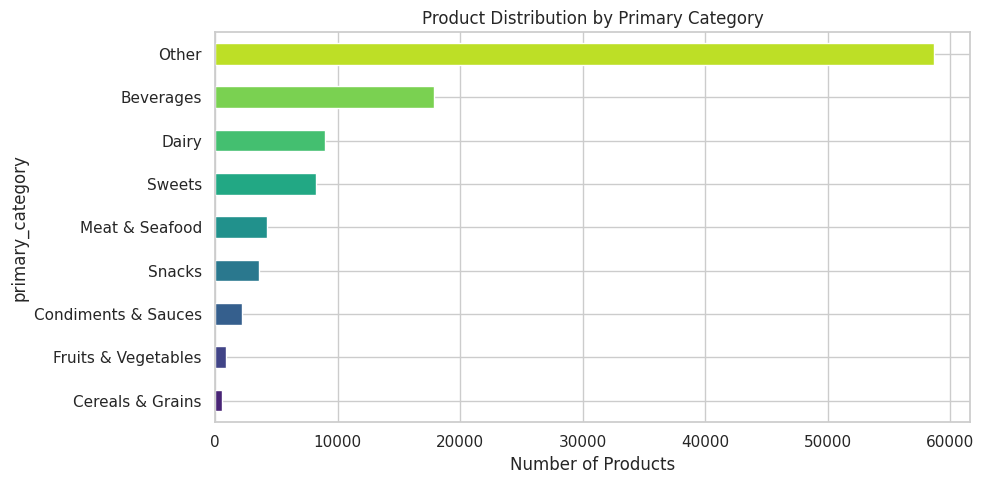

In [25]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from IPython.display import Markdown

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["figure.dpi"] = 100
# Category distribution bar chart
fig, ax = plt.subplots(figsize=(10, 5))
cat_counts.sort_values().plot.barh(ax=ax, color=sns.color_palette("viridis", len(cat_counts)))
ax.set_xlabel("Number of Products")
ax.set_title("Product Distribution by Primary Category")
plt.tight_layout()


STEP 3 — The Nutrient Matrix (Story 3)

Now we build the strategic insight.

We plot:

X-axis → sugars_100g

Y-axis → proteins_100g

Color → Primary_Category : The shaded Blue Ocean quadrant (High Protein + Low Sugar) is where market gaps live.

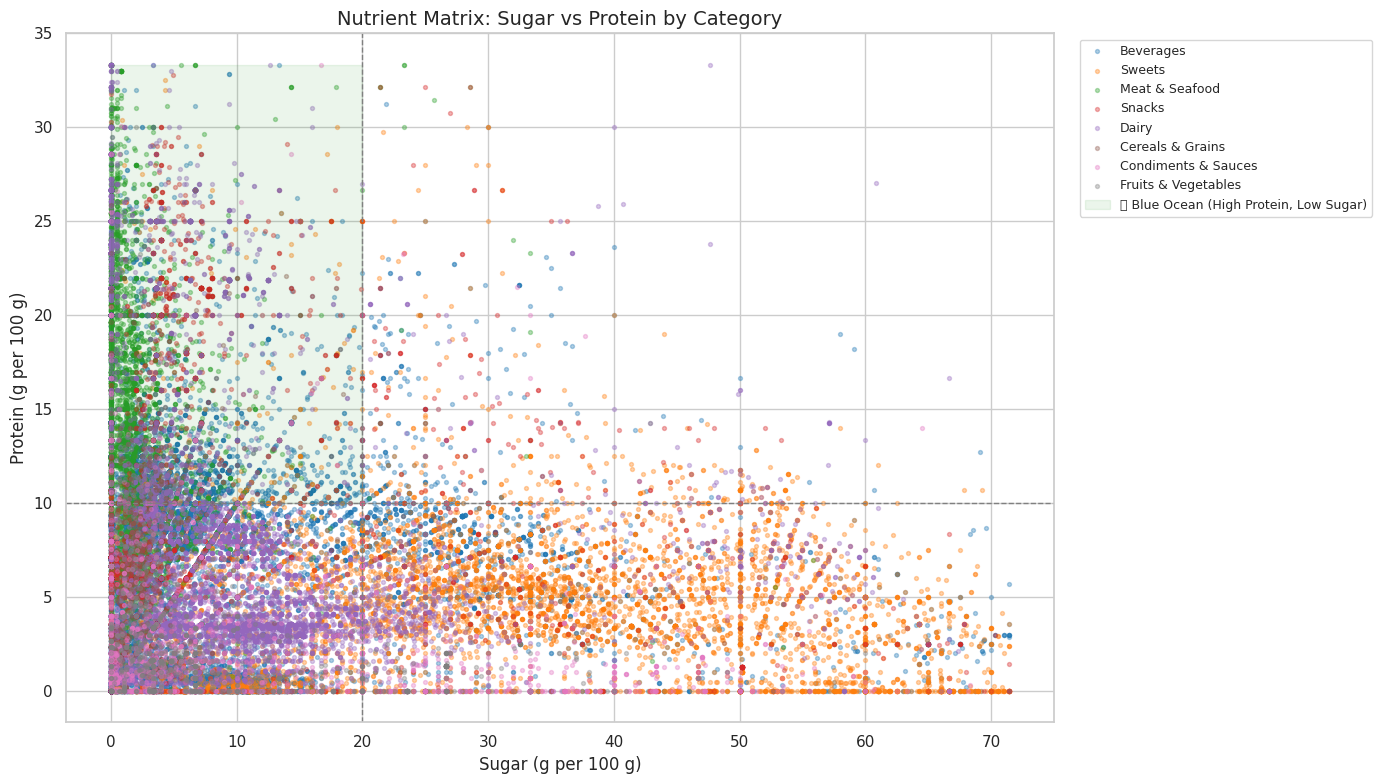

In [26]:
# Define thresholds for the quadrant overlay
SUGAR_THRESHOLD = 20   # g per 100 g
PROTEIN_THRESHOLD = 10  # g per 100 g

# Work with non-Other categories for clarity (Other is noisy)
plot_df = df[df["primary_category"] != "Other"].copy()

fig, ax = plt.subplots(figsize=(14, 8))

# Scatter by category
categories = plot_df["primary_category"].unique()
palette = sns.color_palette("tab10", len(categories))

for cat, color in zip(categories, palette):
    subset = plot_df[plot_df["primary_category"] == cat]
    ax.scatter(subset["sugars_100g"], subset["proteins_100g"],
               label=cat, alpha=0.35, s=8, color=color)

# Quadrant lines
ax.axvline(SUGAR_THRESHOLD, color="grey", ls="--", lw=1)
ax.axhline(PROTEIN_THRESHOLD, color="grey", ls="--", lw=1)

# Highlight the Blue Ocean quadrant
ax.fill_between([0, SUGAR_THRESHOLD], PROTEIN_THRESHOLD, plot_df["proteins_100g"].max(),
                alpha=0.08, color="green", label="🟢 Blue Ocean (High Protein, Low Sugar)")

ax.set_xlabel("Sugar (g per 100 g)", fontsize=12)
ax.set_ylabel("Protein (g per 100 g)", fontsize=12)
ax.set_title("Nutrient Matrix: Sugar vs Protein by Category", fontsize=14)
ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=9)
plt.tight_layout()

In [27]:
# Per-category breakdown: what % of each category falls in the Blue Ocean?
plot_df["blue_ocean"] = (
    (plot_df["sugars_100g"] <= SUGAR_THRESHOLD) &
    (plot_df["proteins_100g"] >= PROTEIN_THRESHOLD)
)

gap = (
    plot_df.groupby("primary_category")["blue_ocean"]
    .agg(["sum", "count"])
    .rename(columns={"sum": "blue_ocean_count", "count": "total"})
)
gap["blue_ocean_pct"] = (gap["blue_ocean_count"] / gap["total"] * 100).round(1)
gap = gap.sort_values("blue_ocean_pct", ascending=False)
print("Blue Ocean penetration by category:\n")
gap

Blue Ocean penetration by category:



,blue_ocean_count,total,blue_ocean_pct
primary_category,,,
Meat & Seafood,3179,4206,75.6
Snacks,1035,3550,29.2
Dairy,2476,8953,27.7
Beverages,4280,17865,24.0
Cereals & Grains,106,580,18.3
Sweets,546,8201,6.7
Condiments & Sauces,125,2209,5.7
Fruits & Vegetables,26,888,2.9


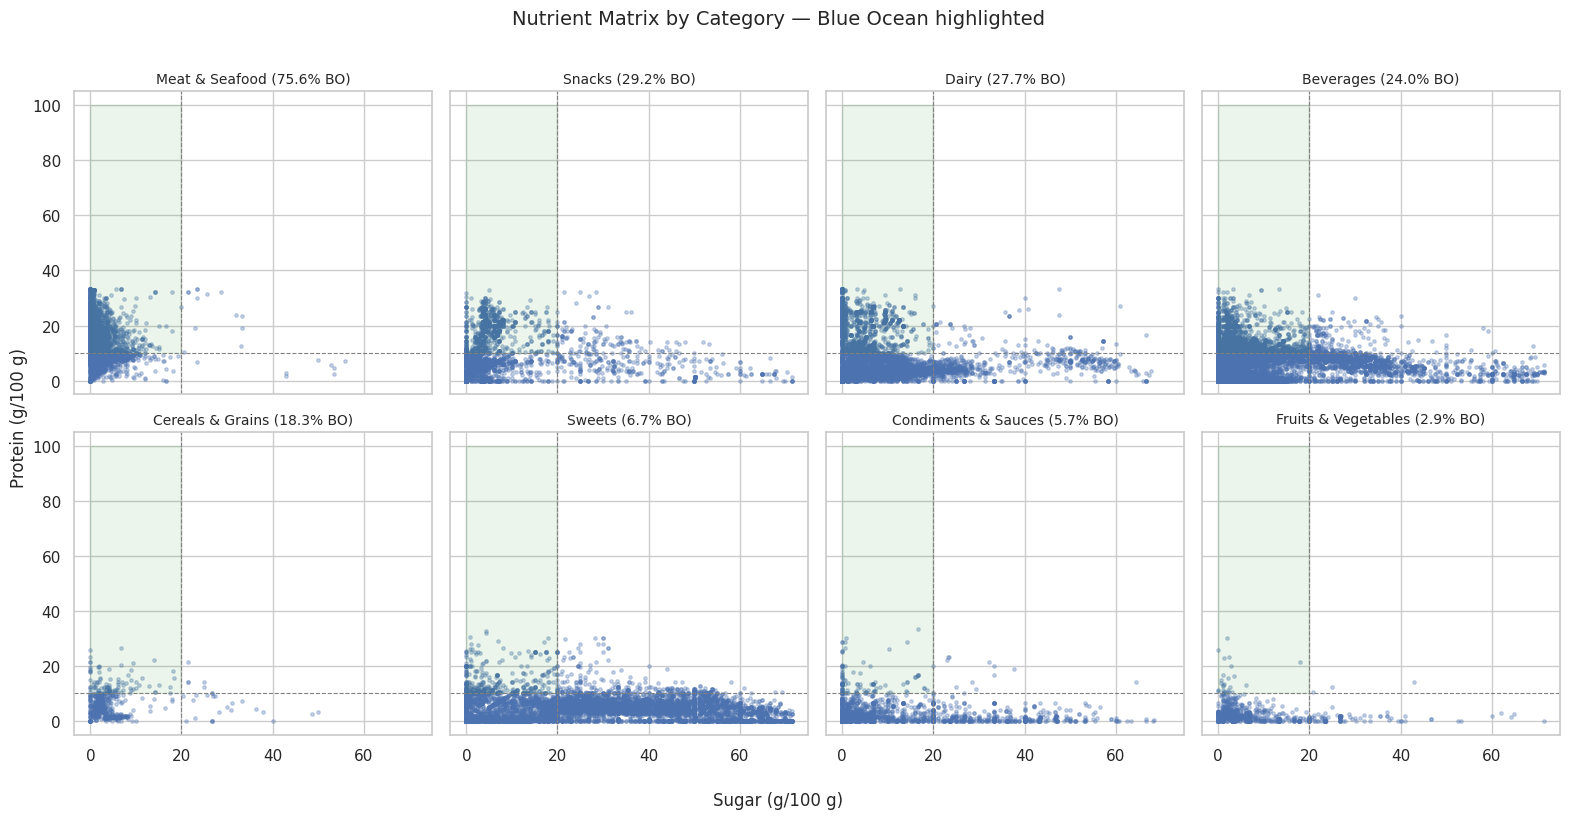

In [28]:
# Faceted scatter: one subplot per category
cats_to_plot = gap.index.tolist()
n = len(cats_to_plot)
cols = 4
rows = int(np.ceil(n / cols))

fig, axes = plt.subplots(rows, cols, figsize=(16, rows * 4), sharex=True, sharey=True)
axes = axes.flatten()

for i, cat in enumerate(cats_to_plot):
    ax = axes[i]
    subset = plot_df[plot_df["primary_category"] == cat]
    ax.scatter(subset["sugars_100g"], subset["proteins_100g"], alpha=0.3, s=6)
    ax.axvline(SUGAR_THRESHOLD, color="grey", ls="--", lw=0.8)
    ax.axhline(PROTEIN_THRESHOLD, color="grey", ls="--", lw=0.8)
    ax.fill_between([0, SUGAR_THRESHOLD], PROTEIN_THRESHOLD, 100,
                    alpha=0.08, color="green")
    ax.set_title(f"{cat} ({gap.loc[cat, 'blue_ocean_pct']}% BO)", fontsize=10)

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

fig.supxlabel("Sugar (g/100 g)", fontsize=12)
fig.supylabel("Protein (g/100 g)", fontsize=12)
fig.suptitle("Nutrient Matrix by Category — Blue Ocean highlighted", fontsize=14, y=1.01)
plt.tight_layout()


STEP 4 — The Recommendation (Story 4)

After counting clusters, we answer:

Which category has LOW competition but some presence in High Protein + Low Sugar?



In [29]:
# Find the category with the LOWEST Blue-Ocean penetration but a meaningful product count
# (i.e., big category where almost nothing is high-protein / low-sugar)
opportunity = gap[gap["total"] >= 500].sort_values("blue_ocean_pct", ascending=True)
print("Categories ranked by gap (lowest Blue-Ocean %):")
opportunity

Categories ranked by gap (lowest Blue-Ocean %):


,blue_ocean_count,total,blue_ocean_pct
primary_category,,,
Fruits & Vegetables,26,888,2.9
Condiments & Sauces,125,2209,5.7
Sweets,546,8201,6.7
Cereals & Grains,106,580,18.3
Beverages,4280,17865,24.0
Dairy,2476,8953,27.7
Snacks,1035,3550,29.2
Meat & Seafood,3179,4206,75.6


In [30]:
# Build recommendation from the top opportunity row
top = opportunity.iloc[0]
top_cat = top.name

# Target specs: aim for 75th-percentile protein among existing BO products in that category
bo_products = plot_df[
    (plot_df["primary_category"] == top_cat) & (plot_df["blue_ocean"])
]

if len(bo_products) > 5:
    target_protein = round(bo_products["proteins_100g"].quantile(0.75))
    target_sugar   = max(5, round(bo_products["sugars_100g"].quantile(0.25)))
else:
    # Fallback: use overall thresholds
    target_protein = PROTEIN_THRESHOLD
    target_sugar   = SUGAR_THRESHOLD // 2

insight = (
    f"Based on the data, the biggest market opportunity is in **{top_cat}**, "
    f"specifically targeting products with **{target_protein} g of protein** "
    f"and less than **{target_sugar} g of sugar** per 100 g.\n\n"
    f"Only **{top['blue_ocean_pct']}%** of the {int(top['total']):,} products in this "
    f"category currently sit in the High-Protein / Low-Sugar quadrant — a clear Blue Ocean."

)

Markdown(f"###  Key Insight\n\n{insight}")

###  Key Insight

Based on the data, the biggest market opportunity is in **Fruits & Vegetables**, specifically targeting products with **17 g of protein** and less than **5 g of sugar** per 100 g.

Only **2.9%** of the 888 products in this category currently sit in the High-Protein / Low-Sugar quadrant — a clear Blue Ocean.

STEP 5 — Bonus: Hidden Gem (Protein Ingredients)

Scan ingredients_text across all Blue-Ocean products and rank the most common protein-rich ingredients.

In [31]:
# High-protein cluster across all categories
hp_df = df[
    (df["proteins_100g"] >= PROTEIN_THRESHOLD) &
    (df["sugars_100g"] <= SUGAR_THRESHOLD) &
    (df["ingredients_text"].notna())
].copy()

print(f"High-Protein / Low-Sugar products with ingredients text: {len(hp_df):,}")

# Known protein-rich ingredient keywords
PROTEIN_KEYWORDS = [
    "whey", "casein", "soy", "pea protein", "egg", "chicken",
    "beef", "pork", "fish", "salmon", "tuna", "turkey",
    "milk", "lentil", "chickpea", "peanut", "almond",
    "oat", "hemp", "collagen", "gelatin", "tofu",
]

counts = {}
for kw in PROTEIN_KEYWORDS:
    counts[kw] = hp_df["ingredients_text"].str.lower().str.contains(kw, na=False).sum()

protein_sources = pd.Series(counts).sort_values(ascending=False)
protein_sources = protein_sources[protein_sources > 0]

print("\nTop protein-source ingredients in Blue-Ocean products:\n")
print(protein_sources.head(10).to_string())

High-Protein / Low-Sugar products with ingredients text: 11,159

Top protein-source ingredients in Blue-Ocean products:

soy        3215
milk       3207
oat        1360
whey        947
chicken     920
pork        798
peanut      754
egg         726
beef        556
almond      410


###  Top 3 Protein Sources

1. **Soy**
2. **Milk**
3. **Oat**

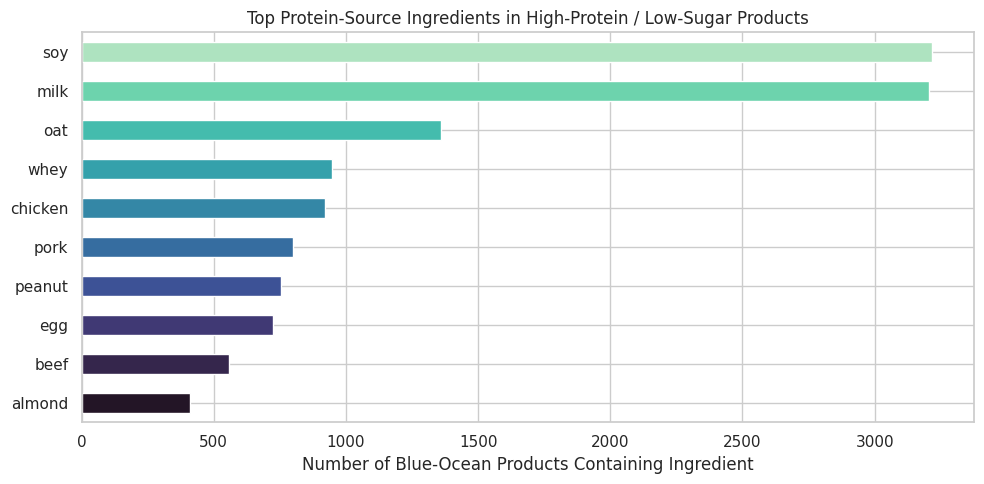

In [33]:
# Visualise top protein sources
top_sources = protein_sources.head(10)

fig, ax = plt.subplots(figsize=(10, 5))
top_sources.sort_values().plot.barh(ax=ax, color=sns.color_palette("mako", len(top_sources)))
ax.set_xlabel("Number of Blue-Ocean Products Containing Ingredient")
ax.set_title("Top Protein-Source Ingredients in High-Protein / Low-Sugar Products")
plt.tight_layout()

top3 = protein_sources.head(3).index.tolist()
Markdown(f"###  Top 3 Protein Sources\n\n"
         f"1. **{top3[0].title()}**\n"
         f"2. **{top3[1].title()}**\n"
         f"3. **{top3[2].title()}**")


STEP 6 — Candidate’s Choice (MY Differentiator)

We will look at "NutriScore Gap Analysis”.

NutriScore (A–E) is increasingly influential on EU packaging. Categories dominated by D/E grades present the biggest on-shelf advantage for a reformulated, healthier product.

In [34]:
# Define your top-level category keywords to map
CATEGORY_MAP = {
    "beverages": "Beverages",
    "dairy": "Dairy",
    "meats": "Meats",
    "fish": "Fish & Seafood",
    "cereals": "Cereals & Grains",
    "snacks": "Snacks",
    "fruits": "Fruits & Vegetables",
    "vegetables": "Fruits & Vegetables",
    "legumes": "Legumes",
    "sauces": "Sauces & Condiments",
    "frozen": "Frozen Foods",
    "sweets": "Sweets",
    "breads": "Breads & Bakery",
}

def assign_category(tags):
    if pd.isna(tags):
        return "Other"
    tags_lower = str(tags).lower()
    for key, label in CATEGORY_MAP.items():
        if key in tags_lower:
            return label
    return "Other"

df["primary_category"] = df["categories_tags"].apply(assign_category)

print(df["primary_category"].value_counts())


primary_category
Other                  63287
Beverages              23378
Snacks                  7340
Dairy                   4159
Sauces & Condiments     2652
Meats                   2175
Frozen Foods            1424
Fish & Seafood           626
Fruits & Vegetables       31
Cereals & Grains          14
Legumes                    7
Breads & Bakery            2
Sweets                     1
Name: count, dtype: int64


In [35]:
# Map NutriScore letters to numeric for aggregation
SCORE_MAP = {"a": 1, "b": 2, "c": 3, "d": 4, "e": 5}

scored = df[df["nutriscore_grade"].isin(SCORE_MAP.keys())].copy()
scored["nutriscore_num"] = scored["nutriscore_grade"].map(SCORE_MAP)

ns_by_cat = (
    scored[scored["primary_category"] != "Other"]
    .groupby("primary_category")["nutriscore_num"]
    .agg(["mean", "count"])
    .rename(columns={"mean": "avg_nutriscore", "count": "scored_products"})
    .sort_values("avg_nutriscore", ascending=False)
)
ns_by_cat["avg_nutriscore"] = ns_by_cat["avg_nutriscore"].round(2)

# Grade distribution per category
grade_dist = pd.crosstab(
    scored[scored["primary_category"] != "Other"]["primary_category"],
    scored[scored["primary_category"] != "Other"]["nutriscore_grade"],
    normalize="index",
) * 100

print("Average NutriScore by Category (1=A, 5=E):\n")
ns_by_cat


Average NutriScore by Category (1=A, 5=E):



,avg_nutriscore,scored_products
primary_category,,
Sweets,5.00,1
Snacks,4.43,6840
Sauces & Condiments,3.98,2413
Legumes,3.71,7
Meats,3.44,2099
Frozen Foods,3.36,1359
Cereals & Grains,3.00,10
Beverages,2.89,20751
Fruits & Vegetables,2.41,29


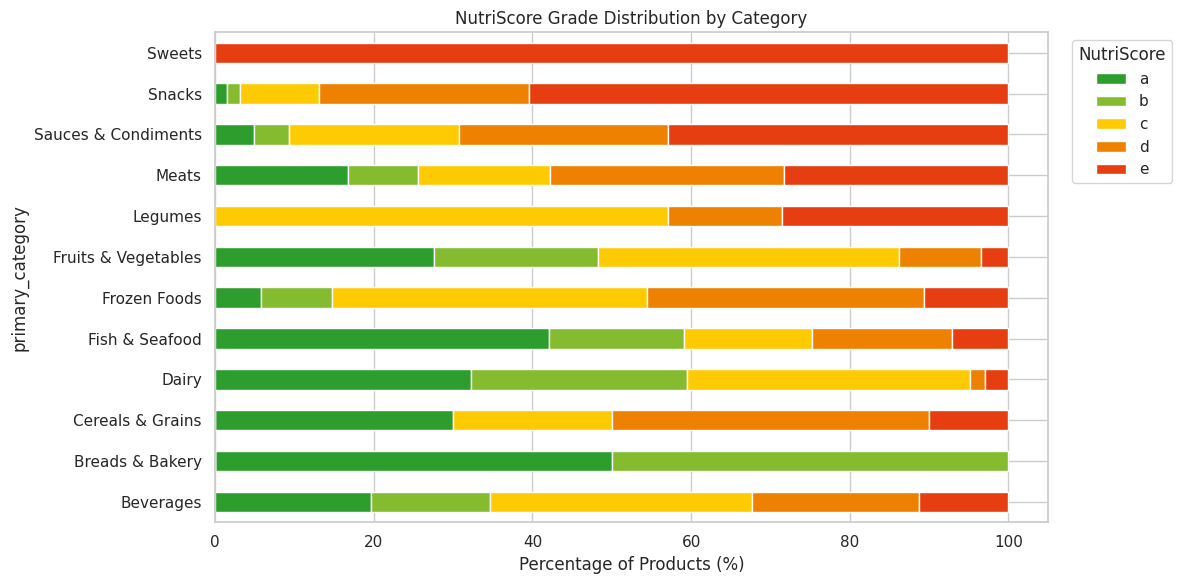

In [37]:
# Stacked bar: NutriScore grade distribution per category
colors = {"a": "#2d9e2d", "b": "#85bb2f", "c": "#fecb02", "d": "#ee8100", "e": "#e63e11"}
grade_order = ["a", "b", "c", "d", "e"]

fig, ax = plt.subplots(figsize=(12, 6))
grade_dist = grade_dist[grade_order]
grade_dist.plot.barh(stacked=True, ax=ax, color=[colors[g] for g in grade_order])

ax.set_xlabel("Percentage of Products (%)")
ax.set_title("NutriScore Grade Distribution by Category")
ax.legend(title="NutriScore", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()


In [38]:
# Final combined insight
worst_ns = ns_by_cat.index[0]

Markdown(
    f"###  Candidate's Choice Insight\n\n"
    f"**{worst_ns}** has the worst average NutriScore across all categories. "
    f"Launching a NutriScore A/B product in this space would provide a "
    f"significant on-shelf competitive advantage, especially in EU markets "
    f"where NutriScore labelling influences purchasing decisions."
)

###  Candidate's Choice Insight

**Sweets** has the worst average NutriScore across all categories. Launching a NutriScore A/B product in this space would provide a significant on-shelf competitive advantage, especially in EU markets where NutriScore labelling influences purchasing decisions.

In [39]:
import os
os.makedirs("data", exist_ok=True)

# 1. Dashboard data: only categorised rows, only the columns the app needs
EXPORT_COLS = [
    "product_name", "brands", "primary_category",
    "sugars_100g", "proteins_100g", "fat_100g", "fiber_100g",
    "nutriscore_grade",
]
export_df = df[df["primary_category"] != "Other"][EXPORT_COLS].copy()
export_df.to_csv("data/dashboard_data.csv", index=False)
print(f"Exported {len(export_df):,} rows to data/dashboard_data.csv")

# 2. Protein sources summary (tiny file)
protein_sources.to_csv("data/protein_sources.csv", header=["count"])
print(f"Exported protein sources to data/protein_sources.csv")


Exported 41,809 rows to data/dashboard_data.csv
Exported protein sources to data/protein_sources.csv
